In [10]:
import pandas as pd

In [11]:
import matplotlib.pyplot as plt

In [12]:
def myfares (mymonth: str) -> float:
    """
    The myfares function takes a 2-character month as the input (in quotation marks, with a leading 0 if needed), and returns the amount of money spent on each day during that month

    Args:
    mymonth (str): This is a 2-character month (as a string) as the input

    Returns:
    mytable (float): This is the amount of money (as a floating point number) spent on each day during that month
    """
    myCab = pd.read_csv("/anvil/projects/tdm/data/taxi/yellow/yellow_tripdata_2018-" + mymonth + ".csv", usecols=[1,16])
    myCab['mydate'] = pd.to_datetime(myCab['tpep_pickup_datetime']).dt.strftime("%Y-%m-%d")
    myCabFare = myCab.groupby('mydate')['total_amount'].sum()
    return myCabFare

In [ ]:
## Displays the myfares function with "01" as input to calculate daily spending totals for January 2018

In [13]:
myfares("01")

mydate
2001-01-05          8.80
2002-12-31         43.26
2003-01-01        165.42
2008-12-31        323.40
2009-01-01        272.49
2017-01-02          2.90
2017-01-03          2.50
2017-12-31       3482.43
2018-01-01    3851903.00
2018-01-02    3733876.40
2018-01-03    4116953.89
2018-01-04    1760411.53
2018-01-05    4045099.72
2018-01-06    4178978.92
2018-01-07    3635668.78
2018-01-08    4285478.73
2018-01-09    4570982.06
2018-01-10    4627360.44
2018-01-11    4977450.01
2018-01-12    5097276.07
2018-01-13    4706551.09
2018-01-14    4237738.74
2018-01-15    3806294.95
2018-01-16    4738687.24
2018-01-17    4658825.15
2018-01-18    5170510.73
2018-01-19    5086014.55
2018-01-20    4367669.50
2018-01-21    3900908.03
2018-01-22    4078434.18
2018-01-23    4415845.88
2018-01-24    4889477.13
2018-01-25    5275927.59
2018-01-26    5274787.90
2018-01-27    4503028.01
2018-01-28    4041012.46
2018-01-29    4227184.11
2018-01-30    4556711.22
2018-01-31    4876567.84
2018-02-01       1

In [ ]:
## Creates a list of all months in a year as 2-character strings 

In [14]:
mymonths = [str(i).zfill(2) for i in range(1,13)]  ## Generates integers from 1 to 12.Converts each integer to a string and pads it with leading zeros if necessary (e.g., "1" becomes "01")
## Applies the myfares function to each month in mymonths and stores the results in a lis
myCabresults = list(map(myfares, mymonths)) ## map(myfares, mymonths): Executes myfares for each month in the list. list(...): Converts the mapped results into a list of Pandas Series objects

In [ ]:
## Combines all monthly results into a single DataFrame and calculates total spending per day across all months.

In [15]:
myCabcounts = pd.concat(myCabresults, axis=1).sum(axis=1)
## Filters daily totals to include only dates from the year 2018.
Cabdates = myCabcounts[pd.to_datetime(myCabcounts.index).strftime("%Y") == "2018"]

In [ ]:
Creates a line plot showing daily spending totals over time in 2018.

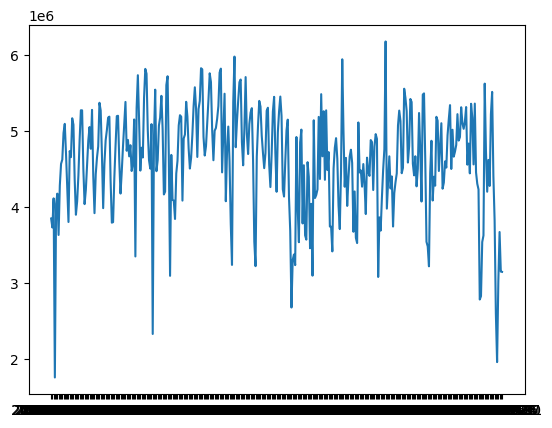

In [16]:
plt.plot(Cabdates.index, Cabdates)